# Notebook 11 · Auditoría de calidad y análisis exploratorio

En este notebook analizamos el dataset maestro generado en el Notebook 10 antes de aplicar técnicas estadísticas posteriores.

El análisis principal utiliza las **22 regiones NUTS 2 de España y Portugal**, que forman el conjunto comparable y no presentan valores analíticos ausentes. Andorra se mantiene como territorio complementario y se revisa por separado, sin imputar los datos no disponibles.

Durante el EDA comprobamos:

1. la estructura y calidad de la matriz;
2. los estadísticos y distribuciones de las variables;
3. la presencia de ceros y valores extremos;
4. las diferencias de escala;
5. las relaciones y posibles redundancias entre variables.

Los resultados se interpretan de forma descriptiva, teniendo en cuenta que solo disponemos de 22 territorios comparables. En este notebook no eliminamos ni transformamos variables y no aplicamos PCA, clustering ni modelos de idoneidad.

In [1]:
# Selección del dataset final del Notebook 10
from pathlib import Path
import zipfile
import numpy as np
import pandas as pd

INPUT_DIR = Path("/kaggle/input")
NOMBRE_01A = "dataset_analitico_comparable_22x78.csv"

def es_version_final_01a(df):
    if df.shape != (22, 78):
        return False
    valor = df.loc[
        df["codigo_geo"].eq("ES11"),
        "electrica_densidad_lineas_km_1000km2"
    ]
    return (
        len(valor) == 1
        and np.isclose(valor.iloc[0], 423.563476)
    )

# Buscamos primero archivos ya descomprimidos
ruta_comparable_01a = None
for ruta in INPUT_DIR.rglob(NOMBRE_01A):
    df_temporal = pd.read_csv(ruta)
    if es_version_final_01a(df_temporal):
        ruta_comparable_01a = ruta
        break

# Si no aparece, buscamos dentro del ZIP corregido
if ruta_comparable_01a is None:
    for ruta_zip in INPUT_DIR.rglob("*.zip"):
        if "notebook_11" not in ruta_zip.name.lower():
            continue

        with zipfile.ZipFile(ruta_zip) as archivo_zip:
            coincidencias = [
                nombre
                for nombre in archivo_zip.namelist()
                if nombre.endswith(NOMBRE_01A)
            ]
            if not coincidencias:
                continue

            with archivo_zip.open(coincidencias[0]) as archivo:
                df_temporal = pd.read_csv(archivo)
            if es_version_final_01a(df_temporal):
                carpeta_01a = Path(
                    "/kaggle/working/entrada_notebook_11_final"
                )
                archivo_zip.extractall(carpeta_01a)
                ruta_comparable_01a = (
                    carpeta_01a / coincidencias[0]
                )
                break

if ruta_comparable_01a is None:
    raise FileNotFoundError(
        "No se encuentra la versión final corregida del Notebook 10."
    )
df_comparable_01a = pd.read_csv(ruta_comparable_01a)
DATOS_DIR_01A = ruta_comparable_01a.parent
PAQUETE_DIR_01A = DATOS_DIR_01A.parent
galicia_01a = df_comparable_01a.loc[
    df_comparable_01a["codigo_geo"].eq("ES11"),
    "electrica_densidad_lineas_km_1000km2"
].iloc[0]

print("Fuente:", ruta_comparable_01a)
print("Dimensiones:", df_comparable_01a.shape)
print("Densidad eléctrica de Galicia:", round(galicia_01a, 6))


Fuente: /kaggle/input/datasets/aemjeloy/ntb-10-corregido/paquete_analisis_notebook_11/01_datos/dataset_analitico_comparable_22x78.csv
Dimensiones: (22, 78)
Densidad eléctrica de Galicia: 423.563476


## Preparación y carga de los datos

Cargamos las matrices y el catálogo de variables generados en el Notebook 10. Antes del análisis exploratorio comprobamos sus dimensiones, claves territoriales y valores ausentes.

In [2]:
# Configuración del Notebook 11
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
RUTA_COMPARABLE = (
    DATOS_DIR_01A
    / "dataset_analitico_comparable_22x78.parquet"
)
RUTA_COMPLETA = (
    DATOS_DIR_01A
    / "dataset_analitico_completo_23x78.parquet"
)
RUTA_CATALOGO = (
    PAQUETE_DIR_01A
    / "02_documentacion"
    / "catalogo_tecnico_maestro_territorial_113_columnas.csv"
)
rutas_entrada_01b = [
    RUTA_COMPARABLE,
    RUTA_COMPLETA,
    RUTA_CATALOGO,
]
if not all(ruta.is_file() for ruta in rutas_entrada_01b):
    raise FileNotFoundError(
        "Faltan archivos del paquete del Notebook 10."
    )

OUTPUT_DIR = Path("/kaggle/working/salidas_notebook_11")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Archivos de entrada: 3")
print("Carpeta de salida:", OUTPUT_DIR)


Archivos de entrada: 3
Carpeta de salida: /kaggle/working/salidas_notebook_11


In [3]:
# Carga de los datos
df_comparable = pd.read_parquet(RUTA_COMPARABLE)
df_completa = pd.read_parquet(RUTA_COMPLETA)
df_catalogo = pd.read_csv(RUTA_CATALOGO)
nulos_andorra_01c = int(
    df_completa.loc[
        df_completa["codigo_geo"].eq("AD")
    ].isna().sum().sum()
)
if not (
    df_comparable.shape == (22, 78)
    and df_completa.shape == (23, 78)
    and len(df_catalogo) == 113
    and df_comparable["codigo_geo"].nunique() == 22
    and df_completa["codigo_geo"].nunique() == 23
    and df_comparable.isna().sum().sum() == 0
    and df_completa.isna().sum().sum() == 20
    and nulos_andorra_01c == 20
):
    raise ValueError("Los datos necesitan revisión.")

print("Comparable:", df_comparable.shape, "| Nulos: 0")
print("Completa:", df_completa.shape, "| Nulos: 20")
print("Catálogo:", df_catalogo.shape)


Comparable: (22, 78) | Nulos: 0
Completa: (23, 78) | Nulos: 20
Catálogo: (113, 7)


## Estructura de la matriz analítica

Separamos los cuatro campos de identificación territorial de las 74 variables analíticas utilizadas en el EDA.

In [4]:
# Estructura de la matriz analítica
columnas_id = [
    "codigo_geo",
    "nombre_territorio",
    "pais",
    "ambito_modelo",
]
columnas_analiticas = [
    c for c in df_comparable.columns
    if c not in columnas_id
]
numericas_02a = df_comparable[
    columnas_analiticas
].select_dtypes(include="number").columns

if len(columnas_analiticas) != 74 or len(numericas_02a) != 74:
    raise ValueError("La estructura analítica necesita revisión.")

print("Identificación: 4 | Variables analíticas: 74")


Identificación: 4 | Variables analíticas: 74


### Variabilidad de las variables

Comprobamos que ninguna de las 74 variables analíticas sea constante en los 22 territorios comparables.

In [5]:
# Variabilidad de las variables
df_analitico = df_comparable[columnas_analiticas].copy()
variables_constantes = df_analitico.columns[
    df_analitico.nunique() <= 1
].tolist()

if variables_constantes:
    raise ValueError(f"Variables constantes: {variables_constantes}")

print("Variables: 74 | Constantes: 0")


Variables: 74 | Constantes: 0


## Estadísticos descriptivos

Resumimos la distribución, la asimetría y la presencia de ceros en las 74 variables analíticas.

### Variables con mayor asimetría y presencia de ceros

Ordenamos las variables según su asimetría y la proporción de valores cero para identificar los casos que requieren más atención. En esta fase no eliminamos ninguna variable.

In [6]:
# Estadísticos descriptivos
resumen_descriptivo = (
    df_analitico.describe().T
    .drop(columns="count")
    .rename(columns={
        "mean": "media",
        "std": "desv_std",
        "min": "minimo",
        "25%": "q1",
        "50%": "mediana",
        "75%": "q3",
        "max": "maximo",
    })
)
resumen_descriptivo["asimetria"] = df_analitico.skew()
resumen_descriptivo["n_ceros"] = df_analitico.eq(0).sum()
resumen_descriptivo["pct_ceros"] = (
    resumen_descriptivo["n_ceros"] / 22 * 100
)

print("Variables resumidas:", len(resumen_descriptivo))
display(resumen_descriptivo.round(3).head(10))

Variables resumidas: 74


,media,desv_std,minimo,q1,mediana,q3,maximo,asimetria,n_ceros,pct_ceros
poblacion_total,2505549.455,2493440.616,324184.000,839095.000,1632063.500,2627295.250,8631862.000,1.532,0,0.000
poblacion_edad_laboral,1639854.000,1683201.341,209251.000,524460.750,1043684.000,1638817.500,5804984.000,1.574,0,0.000
densidad_poblacion,231.605,370.349,17.700,64.975,97.400,217.825,1620.000,3.010,0,0.000
tasa_desempleo,9.268,3.072,5.800,6.925,8.500,10.000,16.500,1.027,0,0.000
nivel_formativo_terciario,38.718,8.912,23.500,33.150,39.750,44.150,56.200,0.032,0,0.000
corine_superficies_artificiales_pct,5.217,6.527,0.884,1.948,3.000,5.176,28.922,2.759,0,0.000
corine_superficies_agricolas_pct,43.179,11.311,24.890,35.391,43.258,50.629,66.271,0.291,0,0.000
corine_zonas_forestales_naturales_pct,50.520,13.099,20.928,40.880,51.155,59.817,72.424,-0.359,0,0.000
corine_humedales_pct,0.877,0.555,0.099,0.508,0.680,1.362,1.835,0.709,0,0.000
corine_masas_agua_pct,0.206,0.576,0.000,0.000,0.047,0.082,2.714,4.298,7,31.818


In [7]:
# Asimetría y ceros
top_asimetria_03b = (
    resumen_descriptivo["asimetria"]
    .abs()
    .nlargest(10)
    .index
)
print("Mayor asimetría:")
display(
    resumen_descriptivo.loc[
        top_asimetria_03b, ["asimetria"]
    ].round(3)
)
print("Mayor porcentaje de ceros:")
display(
    resumen_descriptivo["pct_ceros"]
    .nlargest(10)
    .round(2)
    .to_frame()
)


Mayor asimetría:


,asimetria
corine_masas_agua_pct,4.298
logistica_hamlet_n,4.212
digital_longitud_lineas_telecom_km,4.124
digital_probes_ripe_1000km2,4.119
digital_nodos_distribucion_conexion_n,4.098
logistica_places_total_n,4.023
digital_data_centers_osm_1000km2,3.920
digital_facilities_peeringdb_n,3.285
digital_facilities_peeringdb_1000km2,3.162
digital_torres_mastiles_1000km2,3.160


Mayor porcentaje de ceros:


,pct_ceros
digital_nodos_distribucion_conexion_n,81.82
digital_nodos_distribucion_conexion_1000km2,81.82
digital_facilities_peeringdb_n,54.55
digital_facilities_peeringdb_1000km2,54.55
corine_masas_agua_pct,31.82
digital_data_centers_osm_n,18.18
digital_longitud_lineas_telecom_km,18.18
digital_data_centers_osm_1000km2,18.18
digital_densidad_lineas_telecom_km_1000km2,18.18
digital_exchanges_centrales_telecom_n,9.09


### Revisión de las variables con más ceros

Los ceros se concentran principalmente en algunas variables digitales y en las masas de agua de CORINE. Revisamos su distribución territorial para distinguir entre ausencia registrada y posibles limitaciones de cobertura de las fuentes.

In [8]:
# Revisión territorial de los ceros
variables_revision = [
    "digital_nodos_distribucion_conexion_n",
    "digital_facilities_peeringdb_n",
    "corine_masas_agua_pct",
    "digital_data_centers_osm_n",
    "digital_longitud_lineas_telecom_km",
]
datos_03c = df_comparable.set_index(
    "nombre_territorio"
)[variables_revision]
diagnostico_revision = pd.DataFrame({
    "territorios_no_cero": datos_03c.ne(0).sum(),
    "pct_ceros": datos_03c.eq(0).mean().mul(100).round(1),
    "mediana": datos_03c.median(),
    "maximo": datos_03c.max(),
    "territorio_maximo": datos_03c.idxmax(),
}).rename_axis("variable").reset_index()

display(diagnostico_revision)


,variable,territorios_no_cero,pct_ceros,mediana,maximo,territorio_maximo
0,digital_nodos_distribucion_conexion_n,4,81.8,0.000000,19.000000,Norte
1,digital_facilities_peeringdb_n,10,54.5,0.000000,31.000000,Comunidad de Madrid
2,corine_masas_agua_pct,15,31.8,0.047165,2.714210,Península de Setúbal
3,digital_data_centers_osm_n,18,18.2,2.000000,8.000000,Norte
4,digital_longitud_lineas_telecom_km,18,18.2,0.972102,98.028867,Castilla y León


### Interpretación de la revisión

Los ceros se concentran principalmente en variables digitales y en las masas de agua de CORINE. En las variables digitales indican que la fuente no registró elementos en determinados territorios, pero no demuestran que la infraestructura no exista. En CORINE representan ausencia de superficie clasificada en esa categoría.

Por ahora conservamos estas variables y dejamos documentada esta limitación para decisiones posteriores.

## Revisión de valores extremos

Aplicamos la regla de Tukey para detectar valores situados fuera de los límites:

- límite inferior: `Q1 − 1,5 × IQR`;
- límite superior: `Q3 + 1,5 × IQR`.

Estos valores se revisan de forma descriptiva. No se consideran errores ni se eliminan automáticamente, especialmente porque solo analizamos 22 territorios.

In [9]:
# Valores extremos mediante IQR
q1_04a = df_analitico.quantile(0.25)
q3_04a = df_analitico.quantile(0.75)
iqr_04a = q3_04a - q1_04a
extremos_04a = (
    df_analitico.lt(q1_04a - 1.5 * iqr_04a)
    | df_analitico.gt(q3_04a + 1.5 * iqr_04a)
)
resumen_extremos = pd.DataFrame({
    "n_extremos": extremos_04a.sum(),
    "pct_extremos": extremos_04a.mean().mul(100).round(1),
}).sort_values("n_extremos", ascending=False)
print(
    "Variables con extremos:",
    int(resumen_extremos["n_extremos"].gt(0).sum())
)
display(
    resumen_extremos[
        resumen_extremos["n_extremos"].gt(0)
    ].head(10)
)


Variables con extremos: 44


,n_extremos,pct_extremos
poblacion_total,4,18.2
poblacion_edad_laboral,4,18.2
corine_masas_agua_pct,4,18.2
digital_nodos_distribucion_conexion_n,4,18.2
digital_densidad_lineas_telecom_km_1000km2,4,18.2
digital_nodos_distribucion_conexion_1000km2,4,18.2
electrica_densidad_subestaciones_1000km2,4,18.2
corine_compatibilidad_alta_pct,4,18.2
corine_superficies_artificiales_pct,3,13.6
densidad_poblacion,3,13.6


### Interpretación de los valores extremos

La regla IQR identifica valores extremos en 44 de las 74 variables. Este resultado está relacionado con las diferencias territoriales, la asimetría y la presencia de ceros.

En algunas variables, `Q1` y `Q3` son cero. Por tanto, el IQR también es cero y cualquier valor positivo puede quedar marcado como extremo.

Los valores detectados se conservan, ya que no representan automáticamente errores.

## Relaciones entre variables

Calculamos la correlación de Spearman entre las 74 variables. Este método es adecuado para detectar relaciones monotónicas cuando existen asimetrías, valores extremos y numerosos ceros.

Como solo analizamos 22 territorios, las correlaciones se interpretan de forma exploratoria y no como relaciones causales. Una correlación elevada puede indicar redundancia, pero no implica eliminar automáticamente una variable.

### Interpretación de Spearman

Una relación monotónica indica que, cuando una variable aumenta, la otra tiende a aumentar o disminuir de forma consistente, aunque la relación no sea lineal.

Por ejemplo, la precipitación total y la precipitación media diaria de 2024–2025 contienen información muy similar porque se calculan sobre el mismo periodo. Por ello, mantienen prácticamente el mismo orden territorial y presentan una correlación muy elevada.

Spearman analiza el orden de los valores, mientras que Pearson mide principalmente relaciones lineales.

In [10]:
# Correlaciones de Spearman
from itertools import combinations

corr_spearman = df_analitico.corr(method="spearman")
df_correlaciones = pd.DataFrame(
    [
        (a, b, corr_spearman.loc[a, b])
        for a, b in combinations(columnas_analiticas, 2)
    ],
    columns=[
        "variable_1",
        "variable_2",
        "correlacion_spearman",
    ],
)
df_correlaciones["correlacion_abs"] = (
    df_correlaciones["correlacion_spearman"].abs()
)
df_correlaciones = df_correlaciones.sort_values(
    "correlacion_abs", ascending=False
).reset_index(drop=True)

print("Parejas analizadas:", len(df_correlaciones))
display(df_correlaciones.head(10).round(3))


Parejas analizadas: 2701


,variable_1,variable_2,correlacion_spearman,correlacion_abs
0,solar_radiation_total_mj_m2_2024_2025,solar_radiation_daily_mean_mj_m2_2024_2025,1.000,1.000
1,precipitation_total_mm_2024_2025,precipitation_daily_mean_mm_2024_2025,1.000,1.000
2,pvgis_produccion_anual_kwh_kwp,pvgis_produccion_media_mensual_kwh_kwp,1.000,1.000
3,poblacion_total,poblacion_edad_laboral,0.998,0.998
4,digital_nodos_distribucion_conexion_n,digital_nodos_distribucion_conexion_1000km2,0.997,0.997
5,logistica_road_total_km,logistica_road_alta_capacidad_km,0.991,0.991
6,corine_compatibilidad_baja_pct,corine_compatibilidad_media_pct,-0.982,0.982
7,logistica_road_total_km_por_1000km2,logistica_road_alta_capacidad_km_por_1000km2,0.972,0.972
8,pvgis_irradiacion_anual_kwh_m2,pvgis_produccion_media_mensual_kwh_kwp,0.972,0.972
9,pvgis_produccion_anual_kwh_kwp,pvgis_irradiacion_anual_kwh_m2,0.972,0.972


### Interpretación inicial de las correlaciones

Las correlaciones más elevadas aparecen entre variables que contienen información similar, como totales y medias del mismo periodo, recuentos y densidades o indicadores de una misma familia.

Estos resultados sugieren posibles redundancias, pero no justifican eliminar variables automáticamente. Con solo 22 territorios, las relaciones se consideran exploratorias y servirán para fundamentar decisiones posteriores.

In [11]:
# Correlaciones elevadas
umbrales = [0.70, 0.80, 0.90, 0.95, 0.99]
resumen_correlaciones = pd.DataFrame({
    "umbral": umbrales,
    "parejas": [
        int(df_correlaciones["correlacion_abs"].ge(u).sum())
        for u in umbrales
    ],
})
correlaciones_muy_altas = df_correlaciones[
    df_correlaciones["correlacion_abs"].ge(0.95)
]
display(resumen_correlaciones)
print("Parejas con |r| ≥ 0,95:", len(correlaciones_muy_altas))
display(
    correlaciones_muy_altas[
        ["variable_1", "variable_2", "correlacion_spearman"]
    ].round(3)
)


,umbral,parejas
0,0.70,215
1,0.80,106
2,0.90,39
3,0.95,14
4,0.99,6


Parejas con |r| ≥ 0,95: 14


,variable_1,variable_2,correlacion_spearman
0,solar_radiation_total_mj_m2_2024_2025,solar_radiation_daily_mean_mj_m2_2024_2025,1.000
1,precipitation_total_mm_2024_2025,precipitation_daily_mean_mm_2024_2025,1.000
2,pvgis_produccion_anual_kwh_kwp,pvgis_produccion_media_mensual_kwh_kwp,1.000
3,poblacion_total,poblacion_edad_laboral,0.998
4,digital_nodos_distribucion_conexion_n,digital_nodos_distribucion_conexion_1000km2,0.997
5,logistica_road_total_km,logistica_road_alta_capacidad_km,0.991
6,corine_compatibilidad_baja_pct,corine_compatibilidad_media_pct,-0.982
7,logistica_road_total_km_por_1000km2,logistica_road_alta_capacidad_km_por_1000km2,0.972
8,pvgis_irradiacion_anual_kwh_m2,pvgis_produccion_media_mensual_kwh_kwp,0.972
9,pvgis_produccion_anual_kwh_kwp,pvgis_irradiacion_anual_kwh_m2,0.972


### Comparación entre Pearson y Spearman

Utilizamos Spearman como medida principal por la presencia de asimetrías, valores extremos y ceros. Calculamos Pearson como contraste para comprobar si las relaciones lineales ofrecen resultados diferentes.

In [12]:
# Comparación de correlaciones
corr_pearson = df_analitico.corr(method="pearson")
comparacion_correlaciones = df_correlaciones[
    ["variable_1", "variable_2", "correlacion_spearman"]
].copy()
comparacion_correlaciones["correlacion_pearson"] = [
    corr_pearson.loc[a, b]
    for a, b in zip(
        comparacion_correlaciones["variable_1"],
        comparacion_correlaciones["variable_2"],
    )
]
comparacion_correlaciones["diferencia_abs"] = (
    comparacion_correlaciones["correlacion_spearman"]
    - comparacion_correlaciones["correlacion_pearson"]
).abs()
comparacion_correlaciones = (
    comparacion_correlaciones
    .sort_values("diferencia_abs", ascending=False)
    .reset_index(drop=True)
)

print("Parejas comparadas:", len(comparacion_correlaciones))
display(comparacion_correlaciones.head(10).round(3))


Parejas comparadas: 2701


,variable_1,variable_2,correlacion_spearman,correlacion_pearson,diferencia_abs
0,logistica_city_n,digital_nodos_distribucion_conexion_n,-0.075,0.709,0.784
1,electrica_subestaciones_n,digital_nodos_distribucion_conexion_n,0.052,0.789,0.737
2,corine_zonas_forestales_naturales_pct,digital_probes_ripe_1000km2,0.084,-0.500,0.584
3,corine_compatibilidad_baja_pct,digital_torres_mastiles_1000km2,-0.018,-0.581,0.564
4,corine_compat_media_0_3,digital_torres_mastiles_1000km2,-0.034,0.520,0.554
5,corine_zonas_forestales_naturales_pct,digital_torres_mastiles_1000km2,0.032,-0.516,0.548
6,corine_masas_agua_pct,pvgis_amplitud_mensual_kwh_kwp,-0.358,0.174,0.533
7,logistica_places_n_por_1000km2,digital_torres_mastiles_1000km2,0.674,0.149,0.525
8,logistica_hamlet_n,digital_nodos_distribucion_conexion_1000km2,0.532,0.008,0.524
9,corine_compatibilidad_media_pct,digital_probes_ripe_1000km2,-0.038,0.485,0.524


### Síntesis del análisis de correlaciones

De las 2.701 parejas analizadas, 39 presentan una correlación absoluta de Spearman igual o superior a `0,90`, 14 alcanzan `0,95` y 6 alcanzan `0,99`.

Las relaciones más elevadas aparecen principalmente entre variables derivadas de la misma magnitud o entre indicadores relacionados dentro de una familia. Estos resultados señalan posibles redundancias, pero no implican eliminar variables en esta fase.

## Diferencias de escala

Las variables utilizan unidades y rangos diferentes, como porcentajes, recuentos, kilómetros y densidades.

En este EDA solo revisamos estas diferencias. La estandarización se realizará en un notebook posterior, antes de aplicar técnicas multivariantes.

In [13]:
# Diferencias de escala
resumen_escalas = resumen_descriptivo[
    ["minimo", "maximo"]
].copy()
resumen_escalas["rango"] = (
    resumen_escalas["maximo"]
    - resumen_escalas["minimo"]
)
resumen_escalas = resumen_escalas.sort_values(
    "rango", ascending=False
)

print("Mayores rangos:")
display(resumen_escalas.head(10).round(3))
print("Menores rangos:")
display(
    resumen_escalas.tail(10)
    .sort_values("rango")
    .round(6)
)


Mayores rangos:


,minimo,maximo,rango
poblacion_total,324184.000,8631862.000,8307678.000
logistica_places_poblacion_total,323909.000,7573383.000,7249474.000
poblacion_edad_laboral,209251.000,5804984.000,5595733.000
logistica_road_tramos_n,5043.000,66694.000,61651.000
logistica_places_total_n,246.000,35451.000,35205.000
logistica_hamlet_n,134.000,35092.000,34958.000
electrica_longitud_lineas_km,1410.156,26865.918,25455.763
logistica_road_total_km,1100.149,19736.196,18636.047
logistica_road_alta_capacidad_km,893.363,13427.995,12534.632
electrica_longitud_alta_tension_110kv_km,296.258,9407.312,9111.054


Menores rangos:


,minimo,maximo,rango
pvgis_coef_variacion_mensual,0.128774,0.260215,0.131441
soil_moisture_mean_2024_2025,0.153372,0.377645,0.224274
corine_compat_media_0_3,1.265350,1.695563,0.430213
ambiental_penalizacion_media_0_1,0.244158,0.754452,0.510294
digital_nodos_distribucion_conexion_1000km2,0.000000,1.117659,1.117659
corine_humedales_pct,0.099339,1.835070,1.735731
corine_masas_agua_pct,0.000000,2.714210,2.714210
precipitation_daily_mean_mm_2024_2025,1.018825,3.749060,2.730235
digital_densidad_lineas_telecom_km_1000km2,0.000000,2.826879,2.826879
digital_data_centers_osm_1000km2,0.000000,3.153560,3.153560


### Interpretación de las diferencias de escala

Las variables presentan rangos muy distintos debido a sus diferentes unidades. Esto no afecta al análisis descriptivo, pero podría hacer que las variables con valores mayores dominasen técnicas basadas en distancias o variabilidad.

Por ello, las variables deberán estandarizarse antes de aplicar PCA, clustering u otras técnicas multivariantes en notebooks posteriores.

## Síntesis por familias

Resumimos la asimetría, los ceros y los valores extremos de las variables según su familia temática.

In [14]:
# Resumen del EDA por familias
familias_07a = (
    df_catalogo
    .drop_duplicates("variable")
    .set_index("variable")["familia"]
)
detalle_eda = (
    resumen_descriptivo
    .join(resumen_extremos["n_extremos"])
    .join(familias_07a)
)
if len(detalle_eda) != 74 or detalle_eda["familia"].isna().any():
    raise ValueError("Hay variables sin familia documentada.")
resumen_familias_eda = (
    detalle_eda.groupby("familia")
    .agg(
        variables=("asimetria", "size"),
        asimetria_mediana=(
            "asimetria", lambda x: x.abs().median()
        ),
        variables_con_ceros=(
            "n_ceros", lambda x: x.gt(0).sum()
        ),
        pct_ceros_medio=("pct_ceros", "mean"),
        variables_con_extremos=(
            "n_extremos", lambda x: x.gt(0).sum()
        ),
    )
    .reset_index()
)

display(resumen_familias_eda.round(2))


,familia,variables,asimetria_mediana,variables_con_ceros,pct_ceros_medio,variables_con_extremos
0,Ambiental,7,0.49,1,0.65,3
1,CORINE,10,0.71,1,3.18,6
2,Climática,7,0.49,0,0.00,1
3,Digital,14,3.13,12,27.27,14
4,Eléctrica,6,1.24,0,0.00,5
5,Hídrica,3,0.01,0,0.00,1
6,Logística,13,1.84,1,0.35,9
7,PVGIS,9,0.59,0,0.00,1
8,Socioeconómica,5,1.53,0,0.00,4


### Interpretación del análisis por familias

La familia Digital concentra la mayor asimetría, presencia de ceros y valores extremos. Sus ceros indican ausencia de elementos registrados en las fuentes, pero no demuestran necesariamente que la infraestructura no exista.

La familia Eléctrica ya no presenta ceros con la fuente corregida, aunque cinco de sus seis variables contienen valores extremos. Logística y Socioeconómica también muestran asimetría asociada a las diferencias de tamaño entre territorios.

Climática, Hídrica y PVGIS presentan un comportamiento más regular. Estas diferencias se tendrán en cuenta al preparar posteriormente la matriz multivariante.

## Revisión complementaria de Andorra

Andorra no forma parte de las 22 regiones NUTS 2 comparables y presenta 20 ausencias estructurales en las familias CORINE, Ambiental e Hídrica.

Revisamos la cobertura de sus 74 variables analíticas y comparamos los 54 valores disponibles con los rangos observados en las regiones comparables, sin aplicar imputaciones.

In [15]:
# Cobertura analítica de Andorra
df_andorra = df_completa[
    df_completa["codigo_geo"].eq("AD")
].copy()

if len(df_andorra) != 1:
    raise ValueError("Andorra necesita revisión.")
fila_andorra_08a = (
    df_andorra
    .set_index("codigo_geo")
    .loc["AD", columnas_analiticas]
)
andorra_disponibilidad = pd.DataFrame({
    "familia": familias_07a.reindex(columnas_analiticas),
    "disponible": fila_andorra_08a.notna(),
})
n_disponibles = int(andorra_disponibilidad["disponible"].sum())
n_ausentes = 74 - n_disponibles
resumen_andorra_familias = (
    andorra_disponibilidad
    .groupby("familia")["disponible"]
    .agg(variables="size", disponibles="sum")
    .reset_index()
)
resumen_andorra_familias["ausentes"] = (
    resumen_andorra_familias["variables"]
    - resumen_andorra_familias["disponibles"]
)
if (n_disponibles, n_ausentes) != (54, 20):
    raise ValueError("La cobertura de Andorra necesita revisión.")
print("Andorra: 54 disponibles | 20 ausentes")
display(resumen_andorra_familias)
print("Variables ausentes:")
display(
    andorra_disponibilidad[
        ~andorra_disponibilidad["disponible"]
    ].reset_index(names="variable")
)


Andorra: 54 disponibles | 20 ausentes


,familia,variables,disponibles,ausentes
0,Ambiental,7,0,7
1,CORINE,10,0,10
2,Climática,7,7,0
3,Digital,14,14,0
4,Eléctrica,6,6,0
5,Hídrica,3,0,3
6,Logística,13,13,0
7,PVGIS,9,9,0
8,Socioeconómica,5,5,0


Variables ausentes:


,variable,familia,disponible
0,corine_superficies_artificiales_pct,CORINE,False
1,corine_superficies_agricolas_pct,CORINE,False
2,corine_zonas_forestales_naturales_pct,CORINE,False
3,corine_humedales_pct,CORINE,False
4,corine_masas_agua_pct,CORINE,False
5,corine_excluido_pct,CORINE,False
6,corine_compatibilidad_baja_pct,CORINE,False
7,corine_compatibilidad_media_pct,CORINE,False
8,corine_compatibilidad_alta_pct,CORINE,False
9,corine_compat_media_0_3,CORINE,False


### Interpretación de la cobertura de Andorra

Andorra dispone de 54 de las 74 variables analíticas, lo que representa una cobertura del `72,97 %`.

Las 20 ausencias se concentran en CORINE, Ambiental e Hídrica y se mantienen sin imputar porque no disponemos de información homogénea y comparable en las fuentes usadas. Las demás familias están completas.

Por este motivo, Andorra la conservamos como unidad complementaria y no la incluímos en la matriz principal de 22 regiones NUTS 2.


In [16]:
# Comparación de Andorra
variables_andorra_disponibles = (
    andorra_disponibilidad.query("disponible").index.tolist()
)
comparacion_andorra = (
    df_analitico[variables_andorra_disponibles]
    .agg(["min", "median", "max"])
    .T
    .rename(columns={
        "min": "min_comparable",
        "median": "mediana_comparable",
        "max": "max_comparable",
    })
)
comparacion_andorra["valor_andorra"] = pd.to_numeric(
    fila_andorra_08a[variables_andorra_disponibles]
)
comparacion_andorra["familia"] = familias_07a
comparacion_andorra["fuera_rango"] = (
    comparacion_andorra["valor_andorra"]
    .lt(comparacion_andorra["min_comparable"])
    | comparacion_andorra["valor_andorra"]
    .gt(comparacion_andorra["max_comparable"])
)
n_fuera_rango = int(comparacion_andorra["fuera_rango"].sum())
print("Variables disponibles: 54")
print("Fuera del rango comparable:", n_fuera_rango)

display(
    comparacion_andorra[
        comparacion_andorra["fuera_rango"]
    ].round(3)
)

print("Estado 08B: correcto")

Variables disponibles: 54
Fuera del rango comparable: 20


,min_comparable,mediana_comparable,max_comparable,valor_andorra,familia,fuera_rango
poblacion_total,324184.000,1632063.500,8631862.000,81938.000,Socioeconómica,True
poblacion_edad_laboral,209251.000,1043684.000,5804984.000,59134.000,Socioeconómica,True
tasa_desempleo,5.800,8.500,16.500,1.500,Socioeconómica,True
logistica_road_tramos_n,5043.000,16780.500,66694.000,1517.000,Logística,True
logistica_road_total_km,1100.149,5988.562,19736.196,291.646,Logística,True
logistica_road_alta_capacidad_km,893.363,4156.228,13427.995,149.833,Logística,True
logistica_road_secondary_km,144.621,1648.198,6729.375,141.813,Logística,True
logistica_places_total_n,246.000,1254.000,35451.000,70.000,Logística,True
logistica_places_poblacion_total,323909.000,1016353.500,7573383.000,45511.000,Logística,True
logistica_hamlet_n,134.000,954.000,35092.000,30.000,Logística,True


Estado 08B: correcto


### Interpretación de la posición de Andorra

De las 54 variables disponibles para Andorra, 20 quedan fuera del rango observado en las 22 regiones comparables.

El grupo más numeroso corresponde a indicadores logísticos, aunque también aparecen variables eléctricas, socioeconómicas, climáticas, digitales y de PVGIS. Estas diferencias deben interpretarse teniendo en cuenta el menor tamaño territorial de Andorra, su carácter montañoso y que lo estamos analizando como unidad nacional frente a regiones NUTS 2.

Por ello, Andorra la mantenemos como unidad complementaria y no la incorporamos a la matriz principal de análisis.

## Análisis visual de las distribuciones

Representamos las variables por familias para observar su asimetría, ceros y valores extremos. Los gráficos mantienen las unidades y escalas originales.

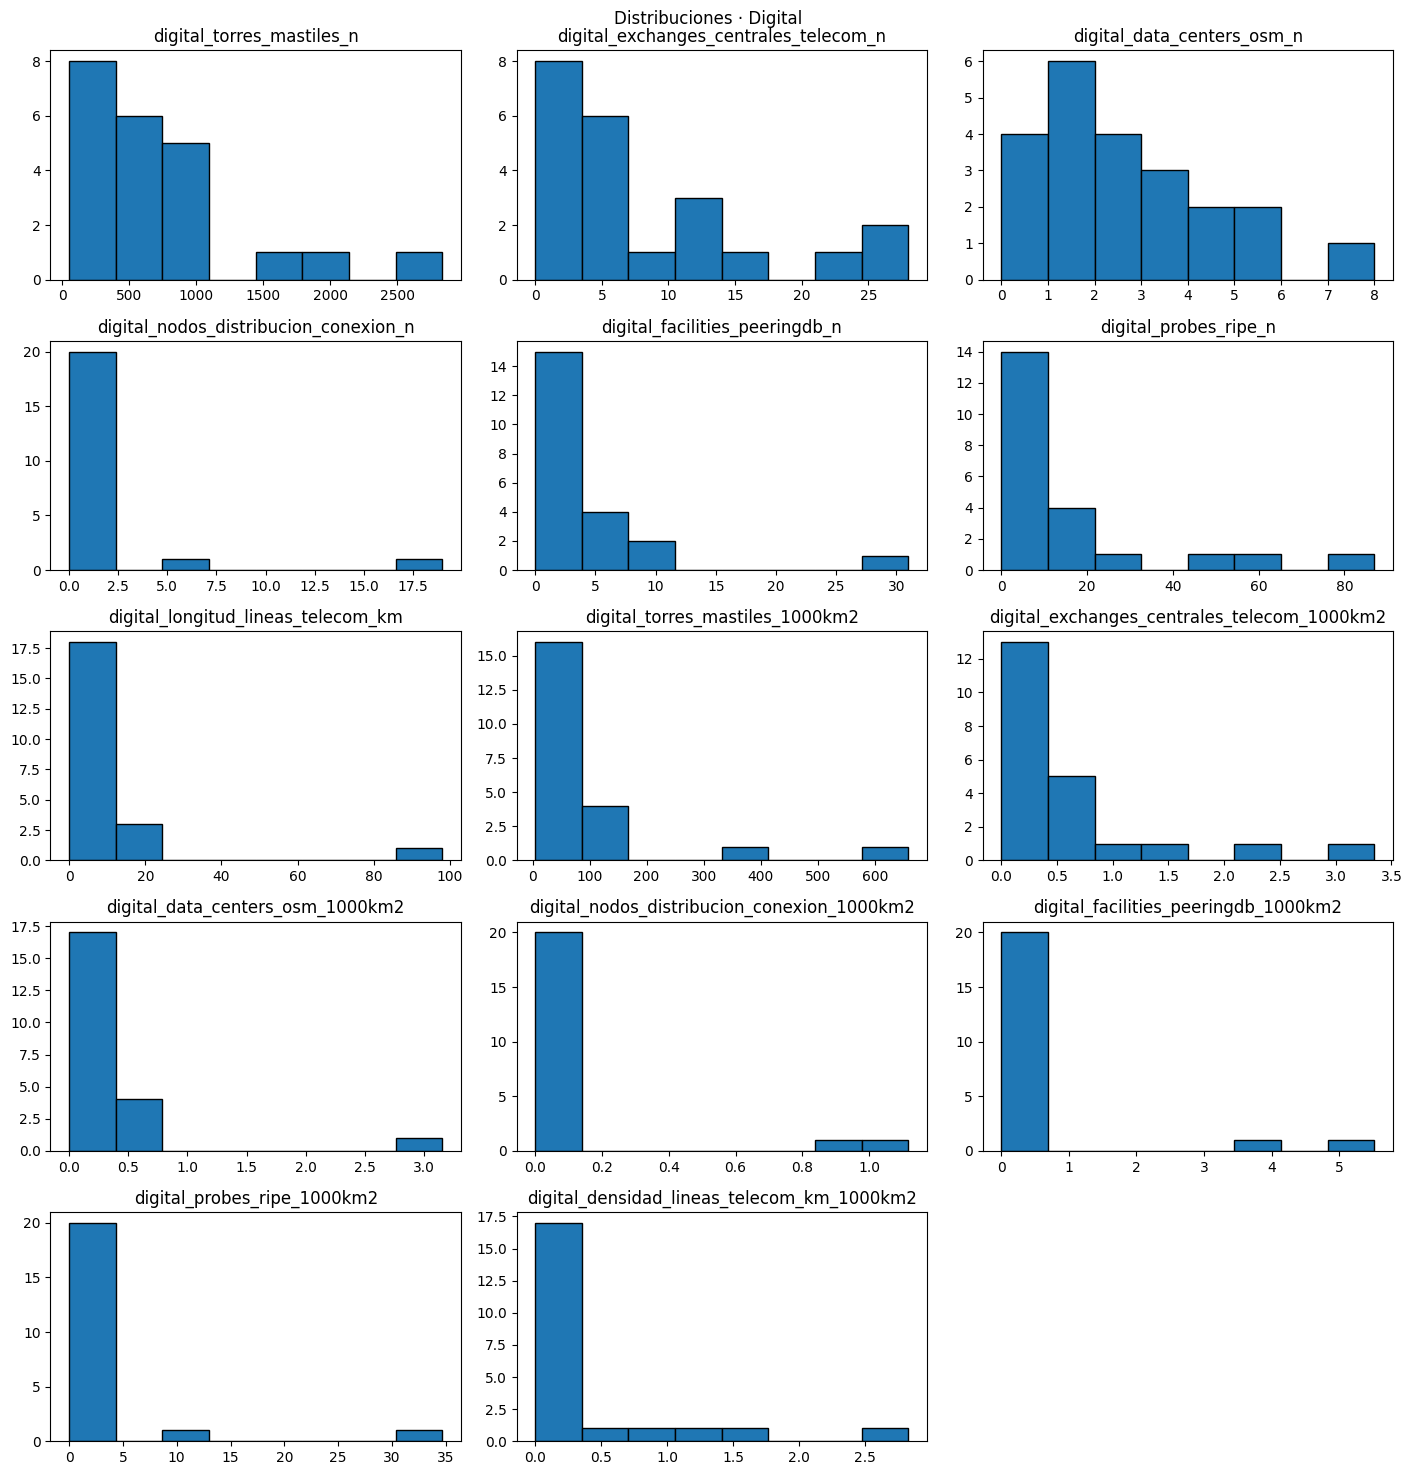

Figuras guardadas: 9
Figura mostrada: Digital


In [17]:
# Distribuciones por familias
FIG_DIR = OUTPUT_DIR / "figuras"
FIG_DIR.mkdir(parents=True, exist_ok=True)

familias_09a = familias_07a.reindex(columnas_analiticas)
rutas_figuras_09a = []
for familia in sorted(familias_09a.unique()):
    variables_09a = familias_09a[
        familias_09a.eq(familia)
    ].index.tolist()
    filas_09a = (len(variables_09a) + 2) // 3
    axes = df_analitico[variables_09a].hist(
        bins=8,
        layout=(filas_09a, 3),
        figsize=(14, 3 * filas_09a),
        edgecolor="black",
        grid=False,
    )
    fig = np.ravel(axes)[0].figure
    fig.suptitle(f"Distribuciones · {familia}")
    fig.tight_layout()
    ruta_09a = FIG_DIR / f"distribuciones_{familia.lower()}.png"
    fig.savefig(ruta_09a, dpi=150, bbox_inches="tight")
    rutas_figuras_09a.append(ruta_09a)

    if familia == "Digital":
        plt.show()
    plt.close(fig)

print("Figuras guardadas:", len(rutas_figuras_09a))
print("Figura mostrada: Digital")


### Mapa de correlaciones

Representamos la matriz de Spearman con las 74 variables ordenadas por familias para observar las relaciones internas y entre grupos temáticos.

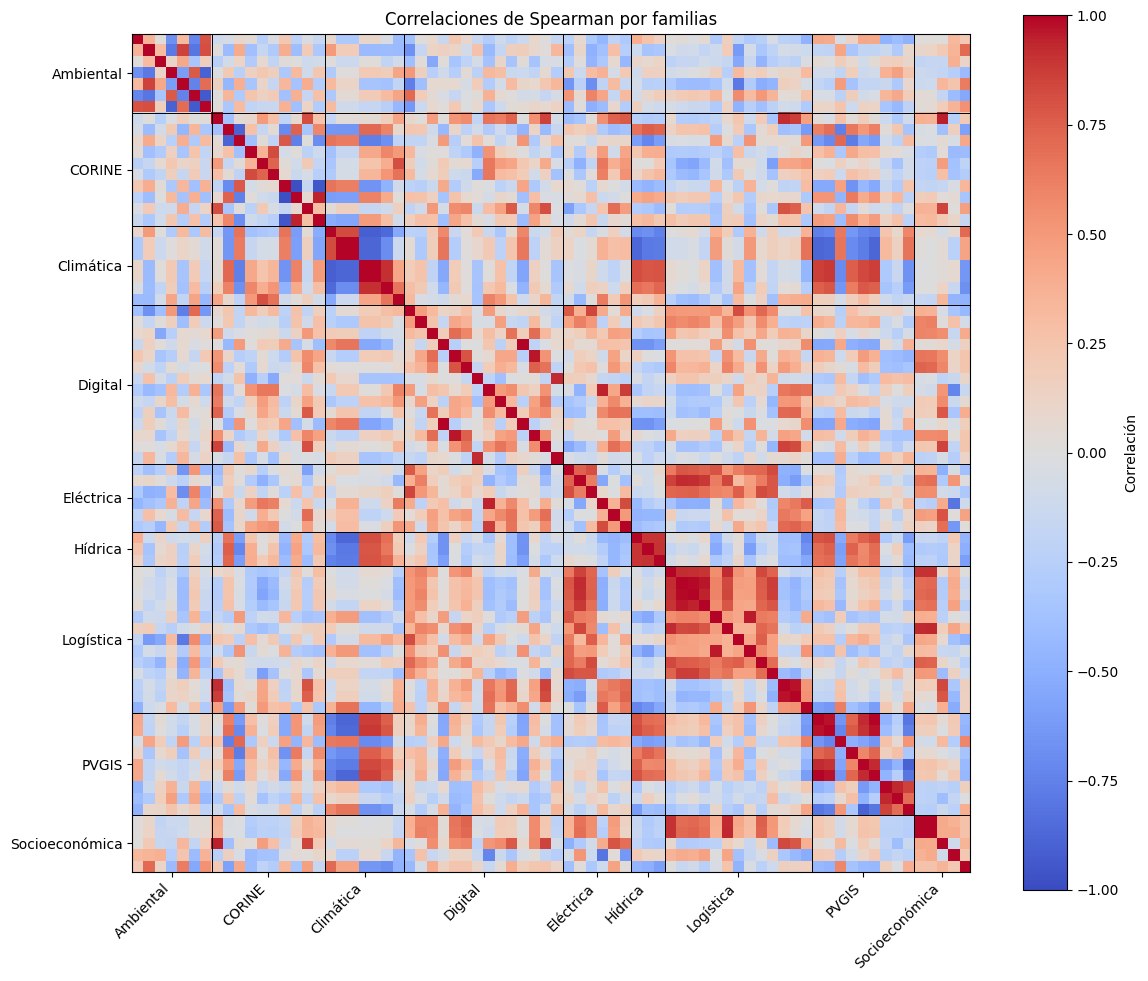

In [18]:
# Mapa de correlaciones
orden_09b = (
    familias_07a
    .reindex(columnas_analiticas)
    .sort_values(kind="stable")
)

variables_ordenadas = orden_09b.index.tolist()

corr_ordenada = corr_spearman.loc[
    variables_ordenadas,
    variables_ordenadas,
]

familias_09b = orden_09b.groupby(
    orden_09b,
    sort=False,
).size()

limites_09b = familias_09b.cumsum()
centros_09b = limites_09b - familias_09b / 2 - 0.5

fig, ax = plt.subplots(figsize=(12, 10))

imagen = ax.imshow(
    corr_ordenada,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

for limite in limites_09b.iloc[:-1]:
    ax.axhline(
        limite - 0.5,
        color="black",
        linewidth=0.7,
    )
    ax.axvline(
        limite - 0.5,
        color="black",
        linewidth=0.7,
    )

ax.set(
    xticks=centros_09b,
    yticks=centros_09b,
    xticklabels=familias_09b.index,
    yticklabels=familias_09b.index,
    title="Correlaciones de Spearman por familias",
)

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
)

fig.colorbar(
    imagen,
    ax=ax,
    label="Correlación",
)

fig.tight_layout()

RUTA_FIG_CORR = FIG_DIR / "matriz_correlaciones_spearman.png"
fig.savefig(
    RUTA_FIG_CORR,
    dpi=180,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)



## Síntesis final del análisis exploratorio

El EDA se ha realizado sobre 74 variables analíticas y 22 regiones NUTS 2 comparables. La matriz está completa, todas las variables son numéricas y ninguna es constante.

Se observan diferencias de escala, asimetrías, ceros y valores extremos en 44 variables. La familia Digital concentra las distribuciones más irregulares, mientras que la familia Eléctrica corregida ya no presenta ceros.

De las 2.701 parejas analizadas, 39 presentan una correlación absoluta de Spearman igual o superior a `0,90` y 14 alcanzan `0,95`. Debido al reducido número de territorios, estas relaciones se interpretan de forma exploratoria.

Andorra dispone de 54 variables y mantiene 20 ausencias estructurales en CORINE, Ambiental e Hídrica, sin aplicar imputaciones. Además, 20 de sus valores disponibles quedan fuera del rango de las regiones comparables, por lo que se conserva como unidad complementaria.

En este notebook no eliminamos ni transformamos variables. Los resultados servirán para fundamentar posteriormente qué indicadores conviene conservar, transformar o excluir antes del análisis multivariante.

## Exportación de resultados

Guardamos las tablas y figuras principales del EDA para documentar el análisis y utilizarlas en notebooks posteriores.

In [19]:
# Exportación del EDA
tablas_11a = {
    "resumen_descriptivo_74_variables.csv":
        resumen_descriptivo.rename_axis("variable").reset_index(),
    "resumen_valores_extremos_iqr.csv":
        resumen_extremos.rename_axis("variable").reset_index(),
    "correlaciones_spearman_pares.csv":
        df_correlaciones,
    "comparacion_pearson_spearman.csv":
        comparacion_correlaciones,
    "resumen_eda_por_familias.csv":
        resumen_familias_eda,
    "disponibilidad_variables_andorra.csv":
        andorra_disponibilidad.rename_axis("variable").reset_index(),
    "comparacion_andorra_regiones_comparables.csv":
        comparacion_andorra.rename_axis("variable").reset_index(),
}

for nombre, tabla in tablas_11a.items():
    tabla.to_csv(
        OUTPUT_DIR / nombre,
        index=False,
        encoding="utf-8-sig",
    )
rutas_tablas_11a = [
    OUTPUT_DIR / nombre
    for nombre in tablas_11a
]
rutas_figuras_11a = rutas_figuras_09a + [RUTA_FIG_CORR]

if not all(ruta.is_file() for ruta in rutas_tablas_11a):
    raise ValueError("La exportación necesita revisión.")

print("Tablas: 7 | Figuras: 10")


Tablas: 7 | Figuras: 10


### Comprobación y paquete final

Comprobamos que las tablas y figuras generadas estén disponibles y las agrupamos en un archivo ZIP para conservar y reutilizar los resultados del EDA.

In [20]:
# Paquete final del EDA
import zipfile

archivos_11b = rutas_tablas_11a + rutas_figuras_11a
if len(archivos_11b) != 17 or not all(
    ruta.is_file() for ruta in archivos_11b
):
    raise FileNotFoundError("Faltan resultados del EDA.")
RUTA_ZIP_FINAL = (
    Path("/kaggle/working")
    / "paquete_final_notebook_11_eda.zip"
)

with zipfile.ZipFile(
    RUTA_ZIP_FINAL,
    "w",
    zipfile.ZIP_DEFLATED,
) as zip_11b:
    for ruta in rutas_tablas_11a:
        zip_11b.write(ruta, f"resultados/{ruta.name}")

    for ruta in rutas_figuras_11a:
        zip_11b.write(ruta, f"figuras/{ruta.name}")

with zipfile.ZipFile(RUTA_ZIP_FINAL) as zip_11b:
    if zip_11b.testzip() or len(zip_11b.namelist()) != 17:
        raise ValueError("El ZIP necesita revisión.")

print("Tablas: 7 | Figuras: 10 | ZIP: 17 archivos")
print("ZIP:", RUTA_ZIP_FINAL)

Tablas: 7 | Figuras: 10 | ZIP: 17 archivos
ZIP: /kaggle/working/paquete_final_notebook_11_eda.zip


## Cierre del Notebook 11

El análisis exploratorio confirma que la matriz principal contiene 22 territorios y 74 variables analíticas completas. Se han documentado las diferencias de escala, la asimetría, los ceros, los valores extremos y las posibles redundancias entre indicadores.

Andorra se mantiene como unidad complementaria, sin imputar sus 20 valores no disponibles. En este notebook no se han eliminado ni transformado variables.

Las tablas y figuras generadas quedan preparadas para fundamentar el tratamiento y la selección de variables en los notebooks posteriores.